# **1. Perkenalan Dataset**

## Diabetes Prediction Dataset

**Sumber:** [Kaggle – Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)

**Deskripsi:**  
Dataset ini berisi data medis dan demografis dari **100.000 pasien** untuk memprediksi apakah seseorang menderita diabetes atau tidak. Dataset mencakup fitur seperti usia, jenis kelamin, indeks massa tubuh (BMI), riwayat hipertensi, riwayat penyakit jantung, riwayat merokok, kadar HbA1c, dan kadar glukosa darah.

**Informasi Fitur:**

| Fitur | Tipe | Deskripsi |
|---|---|---|
| `gender` | Kategorikal | Jenis kelamin pasien (Female, Male, Other) |
| `age` | Numerik (float) | Usia pasien dalam tahun |
| `hypertension` | Biner (int) | 1 = memiliki hipertensi, 0 = tidak |
| `heart_disease` | Biner (int) | 1 = memiliki penyakit jantung, 0 = tidak |
| `smoking_history` | Kategorikal | Riwayat merokok (never, No Info, current, former, ever, not current) |
| `bmi` | Numerik (float) | Body Mass Index |
| `HbA1c_level` | Numerik (float) | Kadar Hemoglobin A1c (indikator rata-rata gula darah 3 bulan) |
| `blood_glucose_level` | Numerik (int) | Kadar glukosa darah saat pemeriksaan |
| `diabetes` | Biner (int) | **Target:** 1 = diabetes, 0 = tidak diabetes |

**Tujuan Proyek:** Membangun model klasifikasi biner untuk memprediksi risiko diabetes berdasarkan fitur-fitur medis dan demografis pasien.

# **2. Import Library**

In [1]:
# ─── Core Data Manipulation ───────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisasi ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ─── Evaluasi Awal (Opsional, digunakan di tahap selanjutnya) ─────────────────
from sklearn.metrics import classification_report, confusion_matrix

# ─── Utilitas ─────────────────────────────────────────────────────────────────
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Semua library berhasil diimport.')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')

✅ Semua library berhasil diimport.
   NumPy   : 2.0.2
   Pandas  : 2.2.2


# **3. Memuat Dataset**

In [2]:
DATASET_PATH = 'diabetes_prediction_dataset.csv'

df_raw = pd.read_csv(DATASET_PATH)

print(f'✅ Dataset berhasil dimuat.')
print(f'   Shape   : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print()
print('── 10 Baris Pertama ──')
df_raw.head(10)

✅ Dataset berhasil dimuat.
   Shape   : 100,000 baris × 9 kolom

── 10 Baris Pertama ──


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini kita akan melakukan EDA komprehensif yang mencakup:
1. Inspeksi tipe data & statistik deskriptif
2. Pemeriksaan missing values & duplikat
3. Distribusi target (class imbalance)
4. Distribusi fitur numerik & kategorikal
5. Analisis korelasi

In [3]:
# ─── 4.1 Informasi Umum Dataset ───────────────────────────────────────────────
print('=' * 55)
print('  4.1  INFO DATASET')
print('=' * 55)
df_raw.info()
print()

  4.1  INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB



In [4]:
# ─── 4.2 Statistik Deskriptif ─────────────────────────────────────────────────
print('=' * 55)
print('  4.2  STATISTIK DESKRIPTIF – FITUR NUMERIK')
print('=' * 55)
df_raw.describe().round(2)

  4.2  STATISTIK DESKRIPTIF – FITUR NUMERIK


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


In [5]:
# ─── 4.3 Missing Values & Duplikat ────────────────────────────────────────────
print('=' * 55)
print('  4.3  MISSING VALUES')
print('=' * 55)
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Null': missing, 'Persentase (%)': missing_pct})
print(missing_df)
print()

print('=' * 55)
print('  4.4  DATA DUPLIKAT')
print('=' * 55)
n_dup = df_raw.duplicated().sum()
print(f'Total baris duplikat : {n_dup:,}')
print(f'Persentase           : {n_dup/len(df_raw)*100:.2f}%')

  4.3  MISSING VALUES
                     Jumlah Null  Persentase (%)
gender                         0             0.0
age                            0             0.0
hypertension                   0             0.0
heart_disease                  0             0.0
smoking_history                0             0.0
bmi                            0             0.0
HbA1c_level                    0             0.0
blood_glucose_level            0             0.0
diabetes                       0             0.0

  4.4  DATA DUPLIKAT
Total baris duplikat : 3,854
Persentase           : 3.85%


In [6]:
# ─── 4.5 Nilai Unik Kolom Kategorikal ─────────────────────────────────────────
print('=' * 55)
print('  4.5  NILAI UNIK KOLOM KATEGORIKAL')
print('=' * 55)
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    vc = df_raw[col].value_counts()
    print(f"\n► {col} ({df_raw[col].nunique()} kategori):")
    print(vc.to_string())

  4.5  NILAI UNIK KOLOM KATEGORIKAL

► gender (3 kategori):
gender
Female    58552
Male      41430
Other        18

► smoking_history (6 kategori):
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004


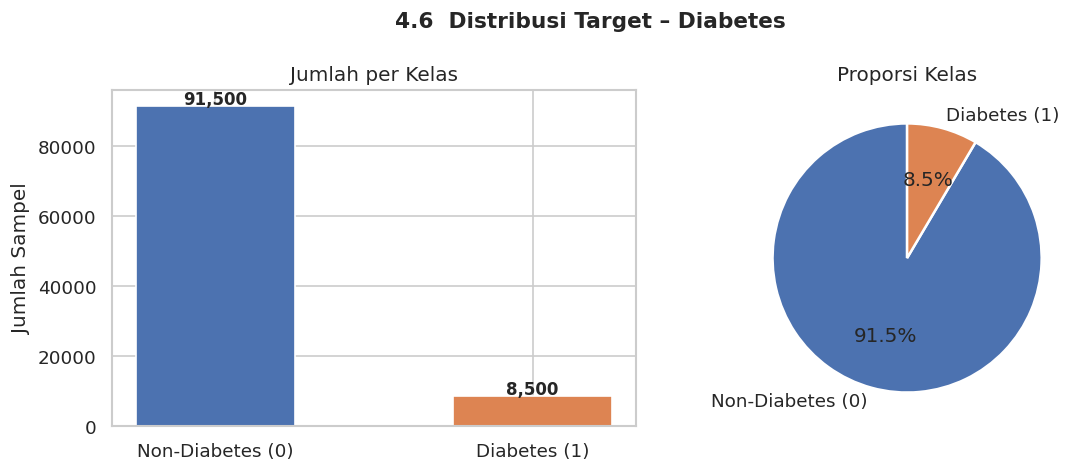


⚠️  Class Imbalance Ratio  →  10.8:1  (Non-Diabetes : Diabetes)
   Pertimbangkan teknik SMOTE atau class_weight pada tahap modeling.


In [7]:
# ─── 4.6 Distribusi Target ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('4.6  Distribusi Target – Diabetes', fontsize=13, fontweight='bold')

target_counts = df_raw['diabetes'].value_counts()
labels = ['Non-Diabetes (0)', 'Diabetes (1)']

# Bar chart
axes[0].bar(labels, target_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_title('Jumlah per Kelas')

# Pie chart
axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', bbox_inches='tight')
plt.show()

ratio = target_counts[0] / target_counts[1]
print(f'\n⚠️  Class Imbalance Ratio  →  {ratio:.1f}:1  (Non-Diabetes : Diabetes)')
print('   Pertimbangkan teknik SMOTE atau class_weight pada tahap modeling.')

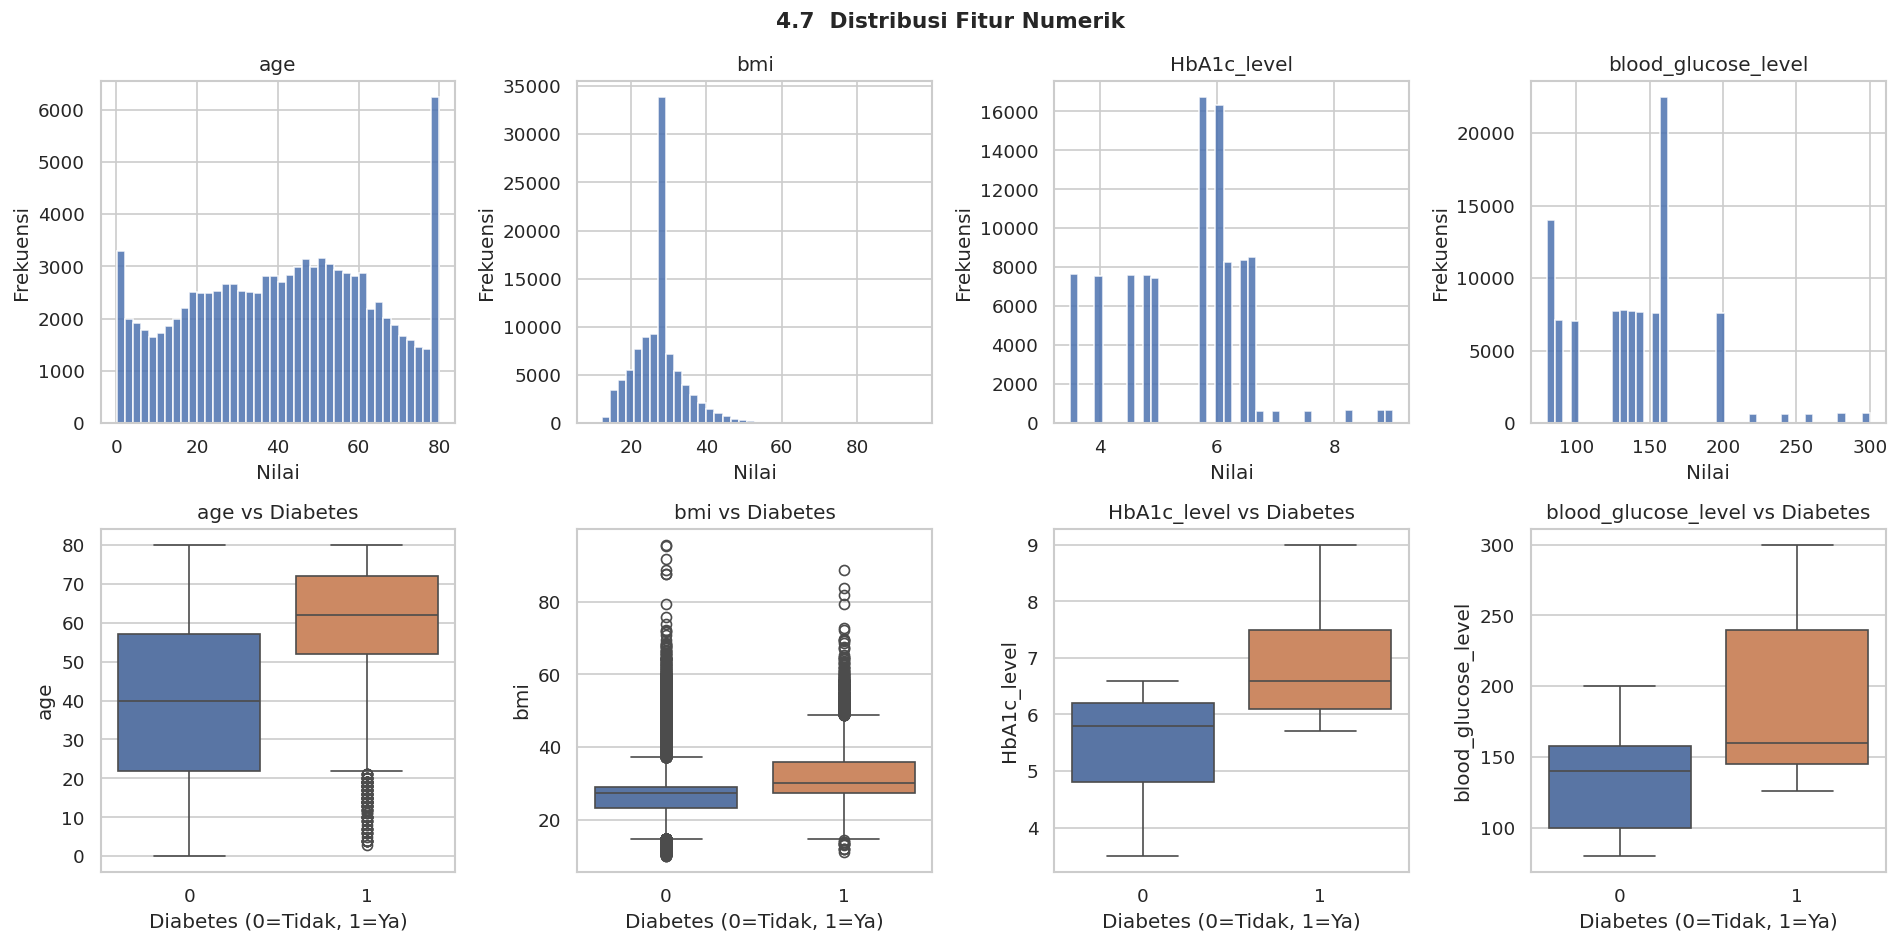

In [9]:
# ─── 4.7 Distribusi Fitur Numerik ─────────────────────────────────────────────
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('4.7  Distribusi Fitur Numerik', fontsize=13, fontweight='bold')

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df_raw[col], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(col)
    axes[0, i].set_xlabel('Nilai')
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot per kelas target (Sudah diperbaiki palette & hue-nya)
    sns.boxplot(data=df_raw, x='diabetes', y=col, ax=axes[1, i], hue='diabetes',
                palette={0: '#4C72B0', 1: '#DD8452', '0': '#4C72B0', '1': '#DD8452'}, legend=False)
    axes[1, i].set_title(f'{col} vs Diabetes')
    axes[1, i].set_xlabel('Diabetes (0=Tidak, 1=Ya)')

plt.tight_layout()
plt.savefig('eda_numeric_distribution.png', bbox_inches='tight')
plt.show()

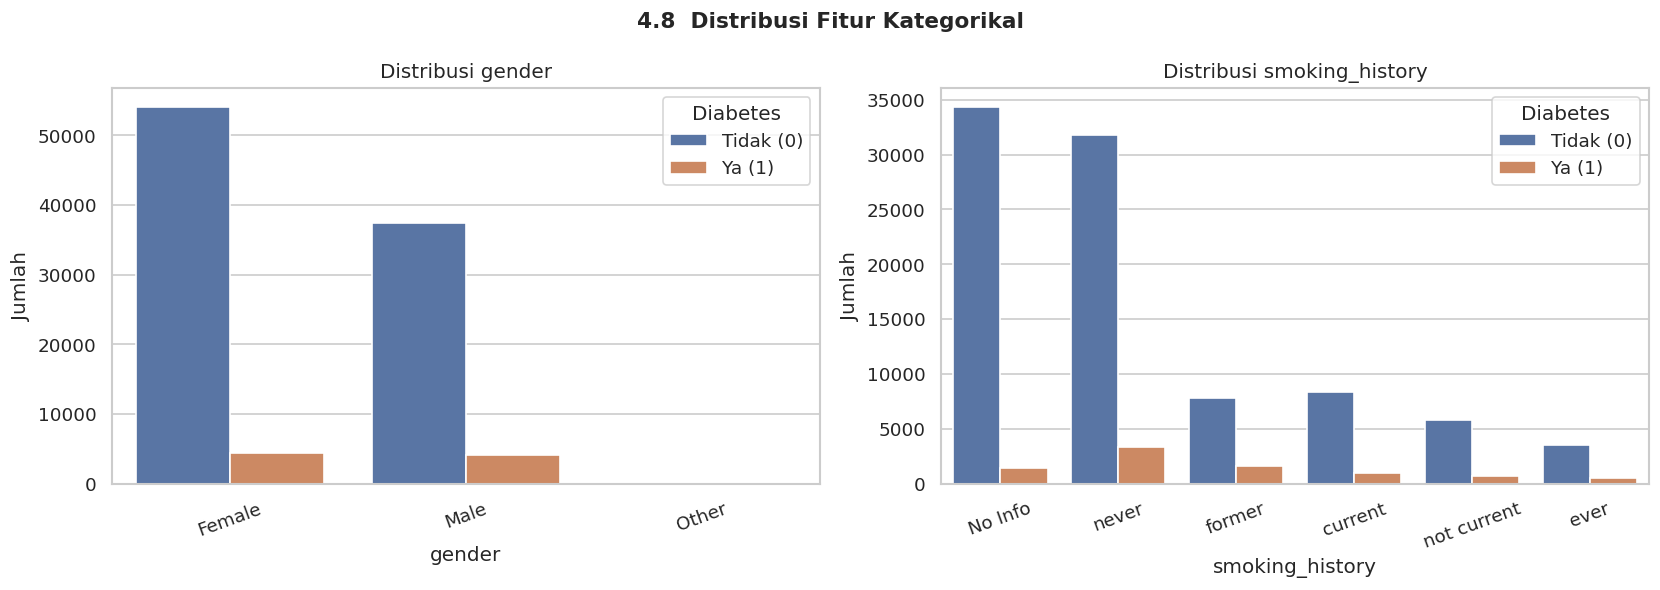

In [10]:
# ─── 4.8 Distribusi Fitur Kategorikal ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('4.8  Distribusi Fitur Kategorikal', fontsize=13, fontweight='bold')

for ax, col in zip(axes, cat_cols):
    order = df_raw[col].value_counts().index
    sns.countplot(data=df_raw, x=col, hue='diabetes', order=order,
                  palette={0: '#4C72B0', 1: '#DD8452', '0': '#4C72B0', '1': '#DD8452'}, ax=ax)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.legend(title='Diabetes', labels=['Tidak (0)', 'Ya (1)'])
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_categorical_distribution.png', bbox_inches='tight')
plt.show()

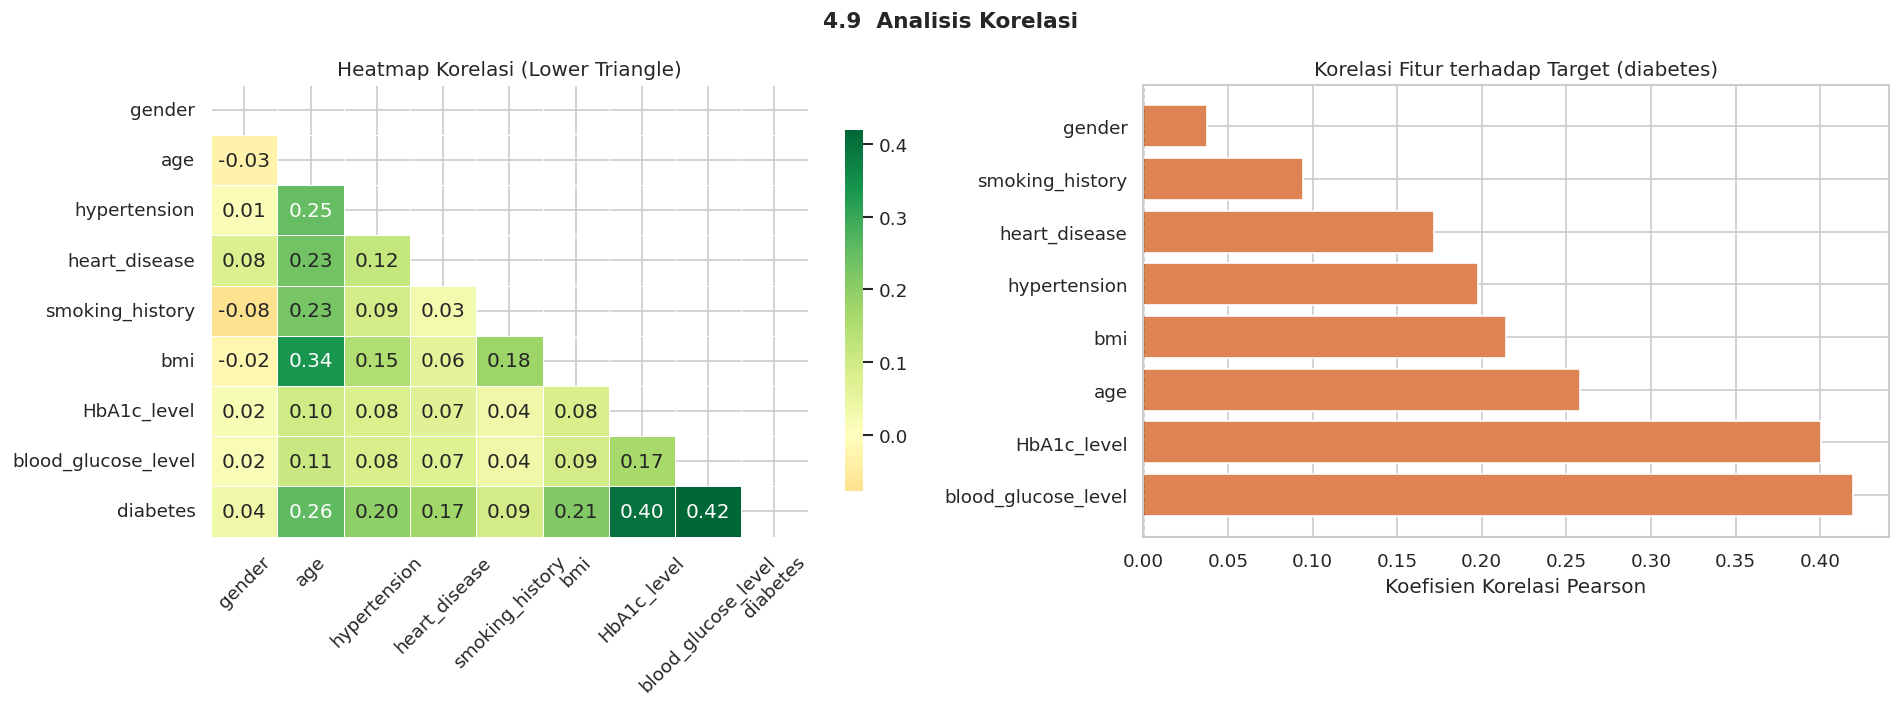


► Top 5 Fitur Paling Berkorelasi dengan Target Diabetes:
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823


In [11]:
# ─── 4.9 Analisis Korelasi ────────────────────────────────────────────────────
# Encode sementara untuk keperluan korelasi
df_corr = df_raw.copy()
for col in cat_cols:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

corr_matrix = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('4.9  Analisis Korelasi', fontsize=13, fontweight='bold')

# Heatmap korelasi penuh
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Heatmap Korelasi (Lower Triangle)')
axes[0].tick_params(axis='x', rotation=45)

# Korelasi terhadap target
corr_target = corr_matrix['diabetes'].drop('diabetes').sort_values(ascending=False)
colors = ['#DD8452' if v >= 0 else '#4C72B0' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Korelasi Fitur terhadap Target (diabetes)')
axes[1].set_xlabel('Koefisien Korelasi Pearson')

plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

print('\n► Top 5 Fitur Paling Berkorelasi dengan Target Diabetes:')
print(corr_target.abs().sort_values(ascending=False).head().to_string())

# **5. Data Preprocessing**

Berdasarkan hasil EDA, tahapan preprocessing yang akan dilakukan:

1. **Hapus Duplikat** — 3.854 baris duplikat ditemukan
2. **Hapus Noise Kategorikal** — kolom `gender` memiliki nilai `'Other'` (jumlah sangat kecil, berpotensi noise)
3. **Encoding Fitur Kategorikal** — `gender` → Binary Encoding | `smoking_history` → Ordinal Encoding
4. **Feature Scaling** — StandardScaler pada fitur numerik kontinyu
5. **Export Dataset Hasil Preprocessing**

In [12]:
# ─── 5.1 Salin Dataset & Hapus Duplikat ───────────────────────────────────────
df = df_raw.copy()

before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'✅  Hapus Duplikat')
print(f'    Sebelum : {before:,} baris')
print(f'    Sesudah : {after:,} baris')
print(f'    Dihapus : {before - after:,} baris')

✅  Hapus Duplikat
    Sebelum : 100,000 baris
    Sesudah : 96,146 baris
    Dihapus : 3,854 baris


In [13]:
# ─── 5.2 Hapus Noise – Gender 'Other' ─────────────────────────────────────────
before = len(df)
df = df[df['gender'] != 'Other'].copy()
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f"✅  Hapus baris dengan gender = 'Other'")
print(f'    Sebelum : {before:,} baris')
print(f'    Sesudah : {after:,} baris')
print(f'    Dihapus : {before - after:,} baris')

✅  Hapus baris dengan gender = 'Other'
    Sebelum : 96,146 baris
    Sesudah : 96,128 baris
    Dihapus : 18 baris


In [14]:
# ─── 5.3 Encoding Fitur Kategorikal ───────────────────────────────────────────

# 5.3.1  gender  →  Binary Encoding (Female=0, Male=1)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
print('✅  gender  →  Binary Encoding  (Female=0, Male=1)')

# 5.3.2  smoking_history  →  Ordinal Encoding
#  Urutan logis: No Info < never < ever < former < not current < current
smoking_order = {
    'No Info'     : 0,
    'never'       : 1,
    'ever'        : 2,
    'former'      : 3,
    'not current' : 4,
    'current'     : 5
}
df['smoking_history'] = df['smoking_history'].map(smoking_order)
print('✅  smoking_history  →  Ordinal Encoding')
print(f'    Mapping: {smoking_order}')
print()
print('── Cek nilai unik setelah encoding ──')
print(f"  gender          : {sorted(df['gender'].unique())}")
print(f"  smoking_history : {sorted(df['smoking_history'].unique())}")

✅  gender  →  Binary Encoding  (Female=0, Male=1)
✅  smoking_history  →  Ordinal Encoding
    Mapping: {'No Info': 0, 'never': 1, 'ever': 2, 'former': 3, 'not current': 4, 'current': 5}

── Cek nilai unik setelah encoding ──
  gender          : [np.int64(0), np.int64(1)]
  smoking_history : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [15]:
# ─── 5.4 Feature Scaling – StandardScaler ─────────────────────────────────────
scale_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print('✅  Feature Scaling – StandardScaler diterapkan pada:')
for col in scale_cols:
    print(f'    {col:<25}  mean={df[col].mean():.6f}  std={df[col].std():.6f}')

✅  Feature Scaling – StandardScaler diterapkan pada:
    age                        mean=0.000000  std=1.000005
    bmi                        mean=0.000000  std=1.000005
    HbA1c_level                mean=-0.000000  std=1.000005
    blood_glucose_level        mean=0.000000  std=1.000005


In [16]:
# ─── 5.5 Validasi Akhir ───────────────────────────────────────────────────────
print('=' * 55)
print('  5.5  VALIDASI DATASET HASIL PREPROCESSING')
print('=' * 55)
print(f'Shape            : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Missing Values   : {df.isna().sum().sum()}')
print(f'Duplikat         : {df.duplicated().sum()}')
print()
print('── Tipe Data ──')
print(df.dtypes.to_string())
print()
print('── Statistik Deskriptif ──')
df.describe().round(4)

  5.5  VALIDASI DATASET HASIL PREPROCESSING
Shape            : 96,128 baris × 9 kolom
Missing Values   : 0
Duplikat         : 0

── Tipe Data ──
gender                   int64
age                    float64
hypertension             int64
heart_disease            int64
smoking_history          int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level    float64
diabetes                 int64

── Statistik Deskriptif ──


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.0000,96128.0000,96128.0000,96128.0000,96128.0000,96128.0000,96128.0000,96128.0000,96128.0000
mean,0.4158,0.0000,0.0776,0.0408,1.4741,0.0000,-0.0000,0.0000,0.0882
std,0.4929,1.0000,0.2676,0.1979,1.6346,1.0000,1.0000,1.0000,0.2836
min,0.0000,-1.8571,0.0000,0.0000,0.0000,-2.5579,-1.8940,-1.4230,0.0000
25%,0.0000,-0.7923,0.0000,0.0000,0.0000,-0.5794,-0.6826,-0.9342,0.0000
50%,0.0000,0.0536,0.0000,0.0000,1.0000,-0.0002,0.2491,0.0436,0.0000
75%,1.0000,0.7658,0.0000,0.0000,3.0000,0.3751,0.6218,0.5080,0.0000
max,1.0000,1.7007,1.0000,1.0000,5.0000,10.1021,3.2308,3.9545,1.0000


In [17]:
# ─── 5.6 Export Dataset Hasil Preprocessing ───────────────────────────────────
OUTPUT_PATH = 'diabetes_prediction_preprocessing.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f'✅  Dataset berhasil disimpan ke: {OUTPUT_PATH}')
print(f'   Shape  : {df.shape}')
print()
print('── 5 Baris Pertama Dataset Final ──')
df.head()

✅  Dataset berhasil disimpan ke: diabetes_prediction_preprocessing.csv
   Shape  : (96128, 9)

── 5 Baris Pertama Dataset Final ──


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700709,0,1,1,-0.314941,0.994547,0.043558,0
1,0,0.543261,0,0,0,-0.000214,0.994547,-1.423041,0
2,1,-0.614187,0,0,1,-0.000214,0.155949,0.483538,0
3,0,-0.258049,0,0,5,-0.572042,-0.496294,0.410208,0
4,1,1.522640,1,1,5,-1.061124,-0.682649,0.410208,0
